In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope

# Load the meticulously cleaned historical data
df = pd.read_csv('../data/cleaned_water_data.csv')

print(f"✅ Baseline Data Loaded. Total Historical Days: {len(df)}")

✅ Baseline Data Loaded. Total Historical Days: 422


In [2]:
# 1. Dynamically extract the 20 Raw Water (RW) input features
features_x = [col for col in df.columns if col.startswith('RW')]
X_raw = df[features_x]

# 2. Initialize and fit the Scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 3. Convert back to a DataFrame just for easier viewing if needed
X_scaled_df = pd.DataFrame(X_scaled, columns=features_x)

print(f"✅ Extracted {len(features_x)} parameters.")
print("✅ Data successfully scaled. Every chemical is now on a level mathematical playing field.")

✅ Extracted 20 parameters.
✅ Data successfully scaled. Every chemical is now on a level mathematical playing field.


In [3]:
# Create 3 copies of a "Normal" day to act as our baseline templates
nightmare_scenarios = pd.DataFrame([X_raw.iloc[0].copy(), X_raw.iloc[0].copy(), X_raw.iloc[0].copy()])
nightmare_scenarios.index = ['Monsoon Mudslide', 'Industrial Spill', 'Biological Threat']

# Scenario 1: Monsoon Mudslide (Massive Dirt/Cloudiness)
nightmare_scenarios.loc['Monsoon Mudslide', 'RW Tur'] = 800
nightmare_scenarios.loc['Monsoon Mudslide', 'RW Colour'] = 100

# Scenario 2: Industrial Spill (Heavy Metals & Salts)
nightmare_scenarios.loc['Industrial Spill', 'RW TDS'] = 2500
nightmare_scenarios.loc['Industrial Spill', 'RW Iron'] = 4.5
nightmare_scenarios.loc['Industrial Spill', 'RW Manganese'] = 1.2

# Scenario 3: Biological Threat (Sewage/Algae Leak)
nightmare_scenarios.loc['Biological Threat', 'RW Fecal coliform'] = 500
nightmare_scenarios.loc['Biological Threat', 'RW Total algal counts'] = 1000

# CRITICAL: We must scale the nightmare data using the EXACT SAME scaler we used on the historical data
nightmare_scaled = scaler.transform(nightmare_scenarios)

print("🧪 Nightmare Test Suite generated and strictly scaled to match historical distributions.")

🧪 Nightmare Test Suite generated and strictly scaled to match historical distributions.


In [6]:
# 1. Initialize the competitors
contamination_rate = 0.02
anomaly_models = {
    "Isolation Forest (Tree)": IsolationForest(contamination=contamination_rate, random_state=42),
    "One-Class SVM (Boundary)": OneClassSVM(nu=contamination_rate),
    "Local Outlier Factor (Density)": LocalOutlierFactor(novelty=True, contamination=contamination_rate),
    "Elliptic Envelope (Stats)": EllipticEnvelope(contamination=contamination_rate, random_state=42)
}

print("ANOMALY DETECTION BAKE-OFF \n" + "="*85)
print(f"{'Algorithm Name':<30} | {'Historical False Alarms':<25} | {'Nightmare Threats Caught (out of 3)'}")
print("-" * 85)

results = {}

# 2. Train and Evaluate Loop
for name, model in anomaly_models.items():
    # Train on the safe historical data
    model.fit(X_scaled)
    
    # Check False Alarms on historical data (Prediction of -1 = Anomaly, 1 = Normal)
    historical_preds = model.predict(X_scaled)
    false_alarms = np.sum(historical_preds == -1)
    
    # Test on the Nightmare Suite
    nightmare_preds = model.predict(nightmare_scaled)
    threats_caught = np.sum(nightmare_preds == -1)
    
    # Store the trained model if it caught all threats
    results[name] = {'model': model, 'false_alarms': false_alarms, 'threats_caught': threats_caught}
    
    # Format the output for the scoreboard
    caught_str = f"✅ {threats_caught}/3 CAUGHT" if threats_caught == 3 else f"❌ {threats_caught}/3 FAILED"
    print(f"{name:<30} | {false_alarms:<25} | {caught_str}")

ANOMALY DETECTION BAKE-OFF 
Algorithm Name                 | Historical False Alarms   | Nightmare Threats Caught (out of 3)
-------------------------------------------------------------------------------------
Isolation Forest (Tree)        | 9                         | ❌ 1/3 FAILED
One-Class SVM (Boundary)       | 23                        | ✅ 3/3 CAUGHT
Local Outlier Factor (Density) | 8                         | ✅ 3/3 CAUGHT
Elliptic Envelope (Stats)      | 9                         | ❌ 2/3 FAILED


C:\Users\Vijayasimha\workspaces\water_quality_monitoring_and_forecasting\venv\Lib\site-packages\sklearn\covariance\_robust_covariance.py:793: UserWarning: The covariance matrix associated to your dataset is not full rank
  warnings.warn(


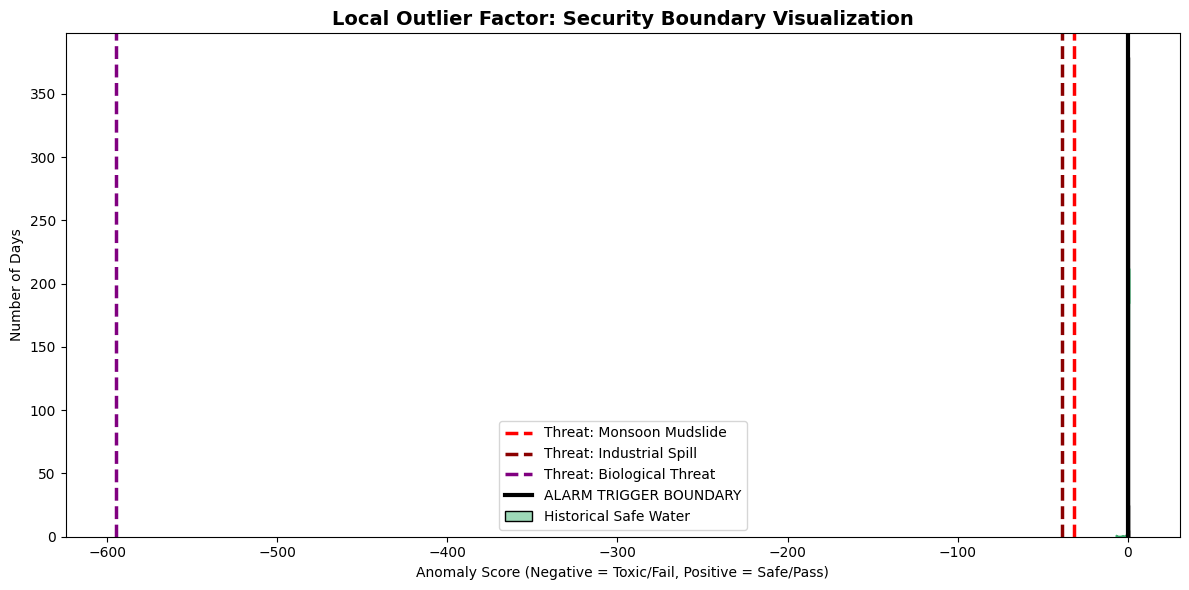

In [8]:
# Select our true champion based on the scoreboard
winner_name = "Local Outlier Factor (Density)"
best_model = anomaly_models[winner_name]

# Get the raw "anomaly scores" (Lower score = more anomalous/dangerous)
# LOF with novelty=True supports decision_function perfectly
historical_scores = best_model.decision_function(X_scaled)
nightmare_scores = best_model.decision_function(nightmare_scaled)

plt.figure(figsize=(12, 6))

# Plot the distribution of safe historical days
sns.histplot(historical_scores, bins=40, color='mediumseagreen', kde=True, label='Historical Safe Water')

# Plot the Nightmare scenarios as specific red lines
colors = ['red', 'darkred', 'purple']
for i, score in enumerate(nightmare_scores):
    scenario_name = nightmare_scenarios.index[i]
    plt.axvline(x=score, color=colors[i], linestyle='--', linewidth=2.5, label=f'Threat: {scenario_name}')

# Draw the 0.0 boundary (Anything to the left of 0 triggers the alarm)
plt.axvline(x=0, color='black', linewidth=3, label='ALARM TRIGGER BOUNDARY')

plt.title('Local Outlier Factor: Security Boundary Visualization', fontsize=14, fontweight='bold')
plt.xlabel('Anomaly Score (Negative = Toxic/Fail, Positive = Safe/Pass)')
plt.ylabel('Number of Days')
plt.legend()
plt.tight_layout()
plt.show()